# Environment Setup


In [ ]:
import numpy as np # linear algebra
from google.colab import drive
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import Markdown
import kagglehub
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import random
import numpy as np
import torch

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# For deterministic behavior with cuDNN (may impact performance)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


#Data Splitting

##Dual stream dataset

In [ ]:
# Define the dual-stream dataset with separate transforms.
class DualStreamDataset(Dataset):
    def __init__(self, org_dir, kmeans_dir, transform_org=None, transform_kmeans=None):
        self.org_dir = org_dir
        self.kmeans_dir = kmeans_dir
        self.transform_org = transform_org
        self.transform_kmeans = transform_kmeans
        self.samples = []

        # Get sorted class names (folder names)
        classes = sorted([d for d in os.listdir(org_dir)
                          if os.path.isdir(os.path.join(org_dir, d))])
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}
        self.classes = classes

        # Loop through each class directory and collect file paths.
        for cls in classes:
            org_class_dir = os.path.join(org_dir, cls)
            kmeans_class_dir = os.path.join(kmeans_dir, cls)
            for fname in os.listdir(org_class_dir):
                if fname.lower().endswith('.jpg'):
                    base_name = os.path.splitext(fname)[0]
                    kmeans_fname = f"{base_name}_final_masked.jpg"
                    org_path = os.path.join(org_class_dir, fname)
                    kmeans_path = os.path.join(kmeans_class_dir, kmeans_fname)
                    if os.path.exists(kmeans_path):
                        label = self.class_to_idx[cls]
                        self.samples.append((org_path, kmeans_path, label))
                    else:
                        print(f"Warning: {kmeans_path} not found.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        org_path, kmeans_path, label = self.samples[index]
        org_image = Image.open(org_path).convert('RGB')
        kmeans_image = Image.open(kmeans_path).convert('RGB')

        # Apply transforms: original image gets augmentation; k-means gets basic transform.
        if self.transform_org:
            org_image = self.transform_org(org_image)
        if self.transform_kmeans:
            kmeans_image = self.transform_kmeans(kmeans_image)

        return org_image, kmeans_image, label

##Original Image Transform

In [ ]:
# Define transform for original images: apply random rotation and color jittering.
org_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Apply color jittering
    T.Resize((224, 224)),  # Resize image to 224x224
    T.ToTensor()  # Convert PIL image to tensor (without normalization)
])

##K-mean image transform

In [ ]:
# Define basic transform for k-means images (only resize and convert to tensor).
kmeans_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

##Create dataset

In [ ]:
# Create the dataset instance.
dataset = DualStreamDataset(
    org_dir="/content/drive/MyDrive/ECSE552/tomato_dataset/color",      # Replace with your original image directory
    kmeans_dir="/content/drive/MyDrive/ECSE552/tomato_dataset/kmean_clustered",  # Replace with your k-means image directory
    transform_org=org_transform,
    transform_kmeans=kmeans_transform
)

# Split dataset into train (80%), validation (10%), and test (10%) sets.
total_samples = len(dataset)
train_size = int(0.7 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Create DataLoaders for each split.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)


##Verify result (Optional)

In [ ]:
# Example: iterate through one batch from the training loader and print shapes.
for org_img, kmeans_img, labels in train_loader:
    print("Original image batch shape:", org_img.shape)
    print("K-means image batch shape:", kmeans_img.shape)
    print("Labels:", labels)
    break

Original image batch shape: torch.Size([32, 3, 224, 224])
K-means image batch shape: torch.Size([32, 3, 224, 224])
Labels: tensor([9, 4, 1, 7, 2, 6, 0, 6, 4, 7, 2, 7, 0, 7, 4, 7, 5, 9, 2, 0, 7, 4, 7, 7,
        7, 7, 2, 0, 7, 4, 7, 8])


## Display data sample

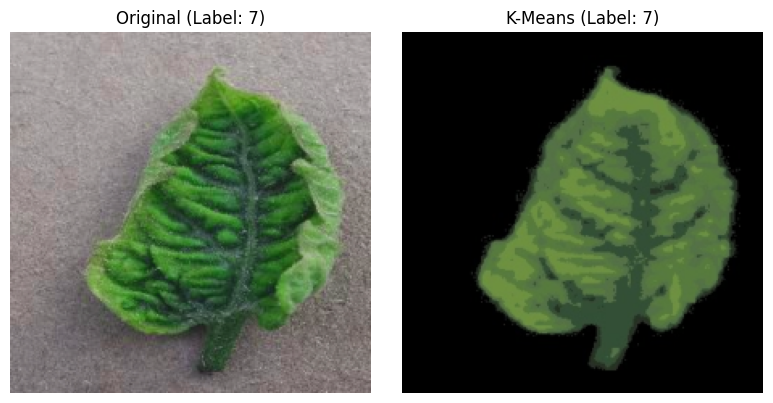

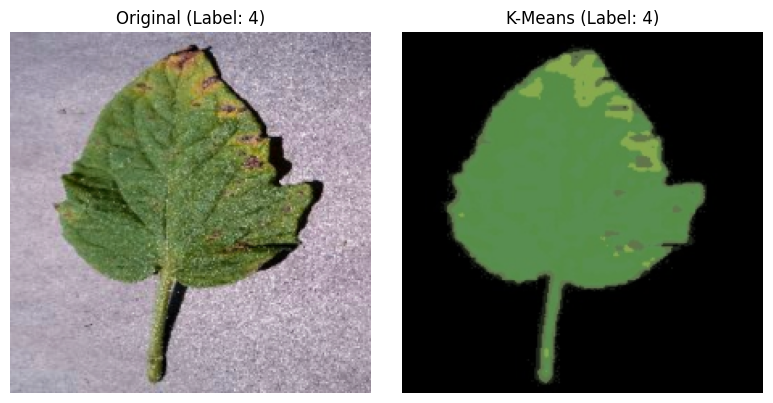

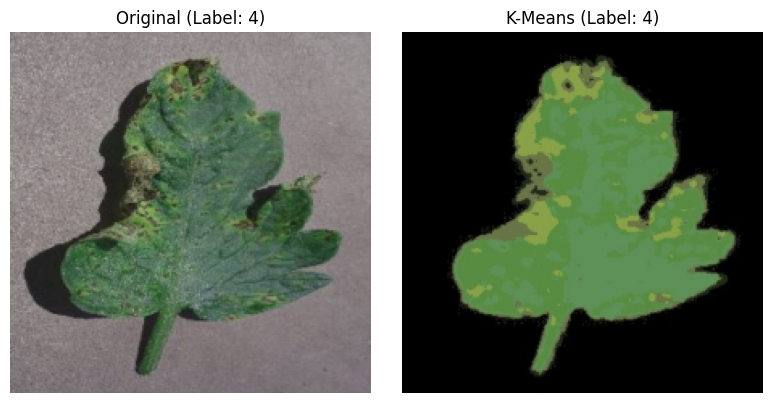

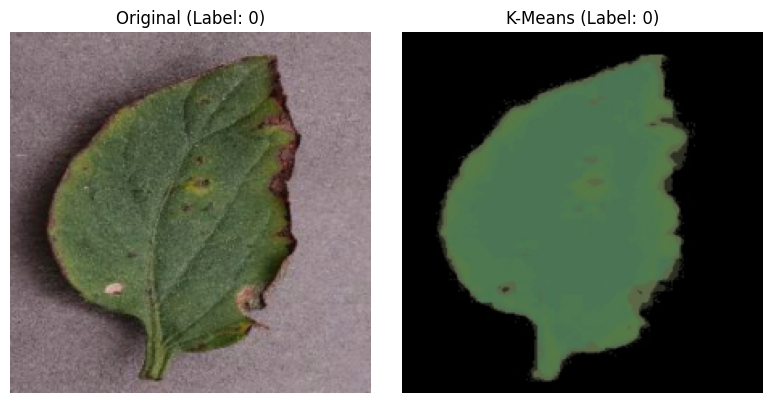

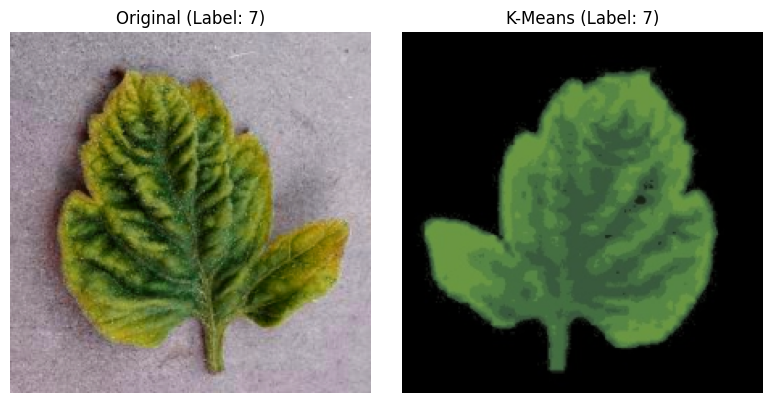

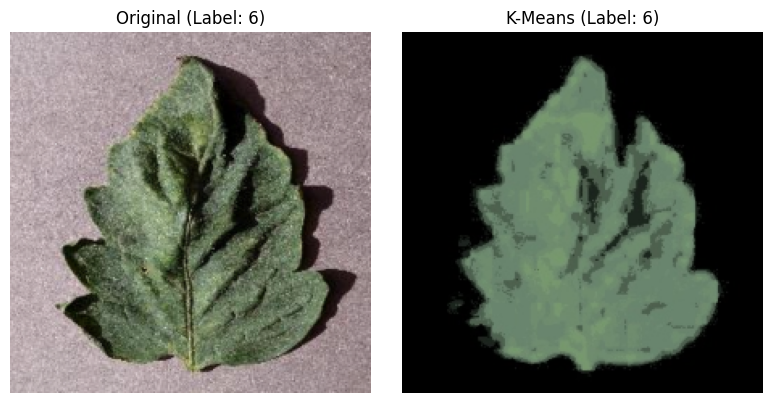

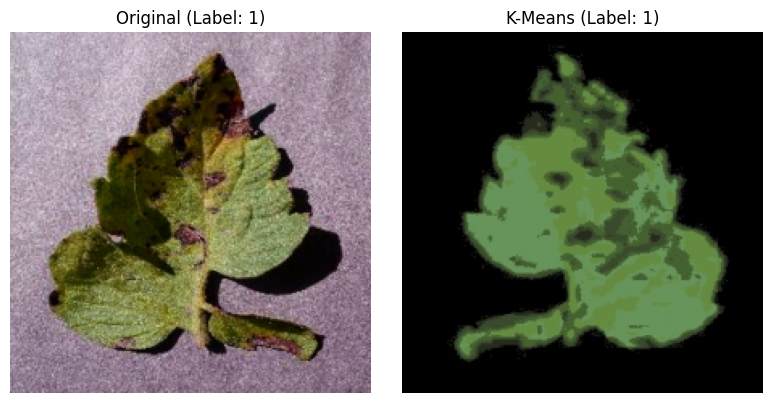

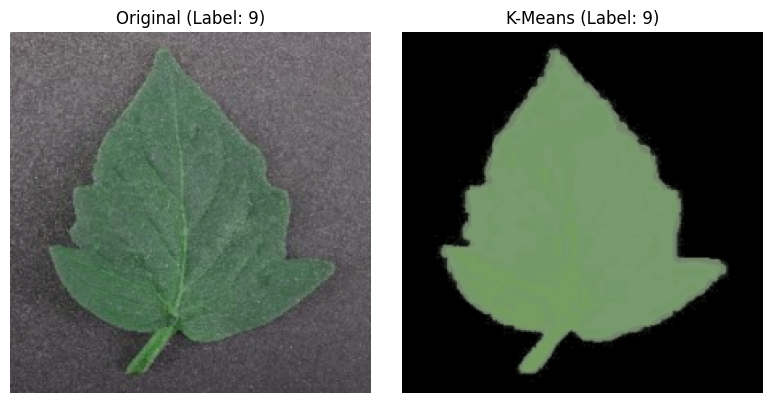

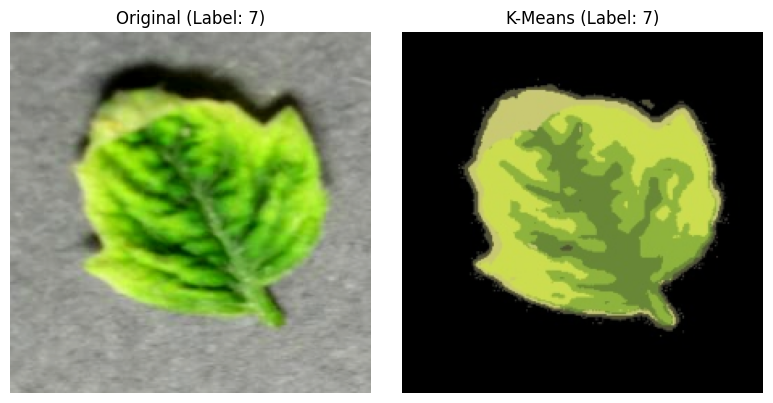

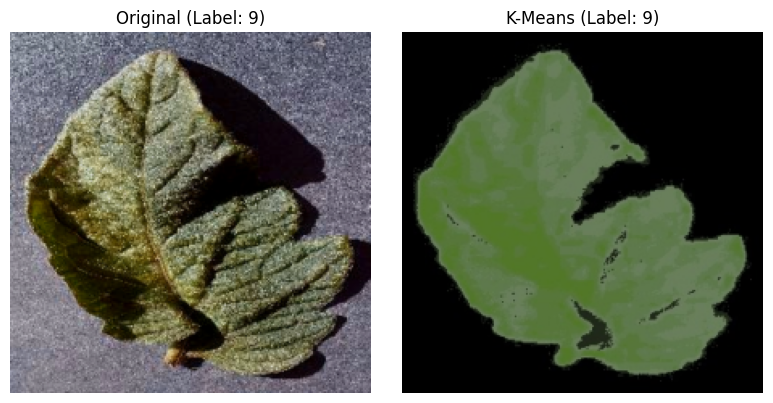

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Suppose you already have a train_loader:
# train_loader = DataLoader(train_dataset, ...)

# Grab one batch of data from the loader.
data_iter = iter(train_loader)
org_batch, kmeans_batch, labels = next(data_iter)

# If you have a list of class names from your dataset, you can use it for a nicer title.
# For example:
# class_names = dataset.classes  # If your dataset has an attribute .classes
class_names = None  # Or replace with the actual class list

# Let's display the first 10 samples in the batch (or fewer if batch_size < 10).
num_to_show = min(10, org_batch.size(0))

def denormalize_and_convert(img_tensor):
    """
    Optional helper to convert a normalized tensor (C,H,W) to a NumPy (H,W,C) for display.
    If you used mean/std normalization, you can unnormalize here.
    """
    # Example for standard ImageNet mean/std:
    # mean = np.array([0.485, 0.456, 0.406])
    # std = np.array([0.229, 0.224, 0.225])
    #
    # img_tensor = img_tensor * torch.tensor(std).view(3,1,1)
    # img_tensor = img_tensor + torch.tensor(mean).view(3,1,1)

    # Convert from (C, H, W) to (H, W, C) and clamp to valid range
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np, 0, 1)
    return img_np

for i in range(num_to_show):
    org_img = denormalize_and_convert(org_batch[i])
    kmeans_img = denormalize_and_convert(kmeans_batch[i])
    label_idx = labels[i].item()

    fig, axs = plt.subplots(1, 2, figsize=(8, 4))

    # Show original image
    axs[0].imshow(org_img)
    if class_names is not None:
        axs[0].set_title(f"Original (Label: {label_idx}, {class_names[label_idx]})")
    else:
        axs[0].set_title(f"Original (Label: {label_idx})")
    axs[0].axis('off')

    # Show k-means image
    axs[1].imshow(kmeans_img)
    if class_names is not None:
        axs[1].set_title(f"K-Means (Label: {label_idx}, {class_names[label_idx]})")
    else:
        axs[1].set_title(f"K-Means (Label: {label_idx})")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
#Check consistency
import os

folder_path = "/content/drive/MyDrive/ECSE552/tomato_dataset/kmean_clustered/Tomato___Bacterial_spot"
# List all entries in the folder
entries = os.listdir(folder_path)
# Filter only files (not directories)
files = [f for f in entries if os.path.isfile(os.path.join(folder_path, f))]
print("Number of files:", len(files))

Number of files: 2127


## image for slides

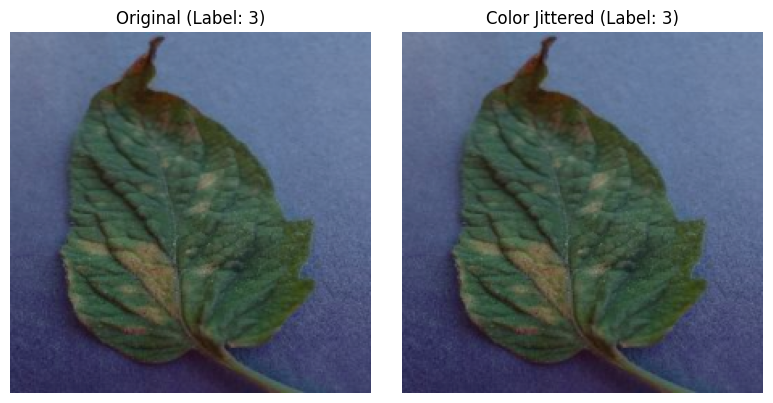

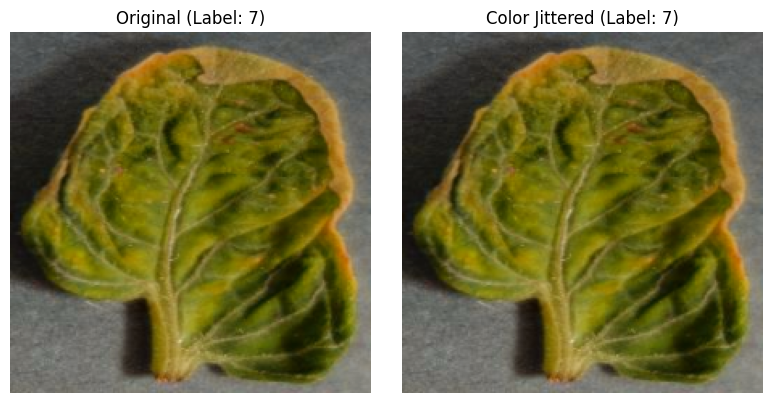

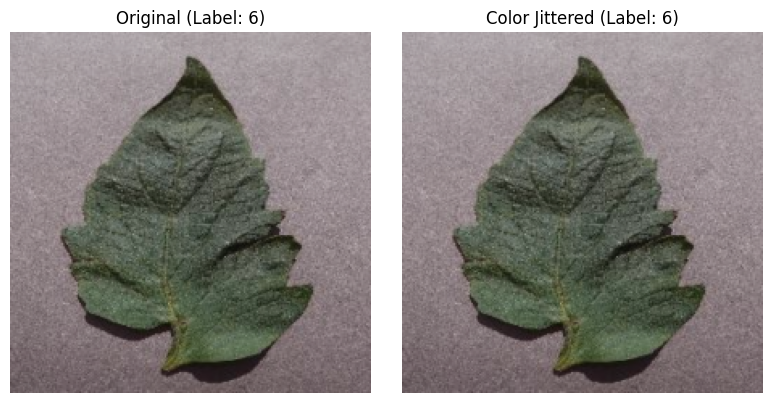

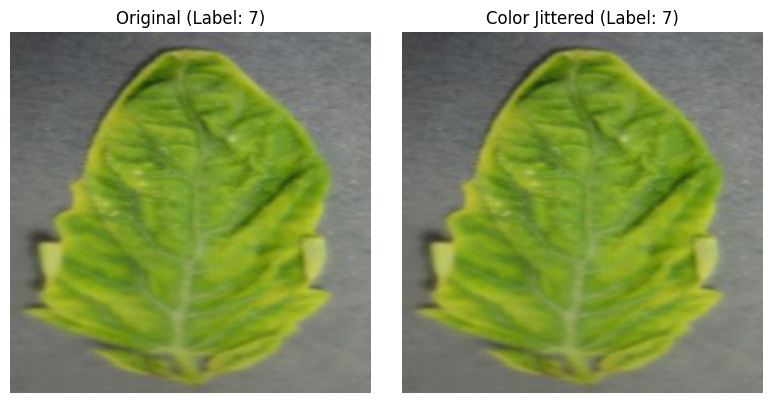

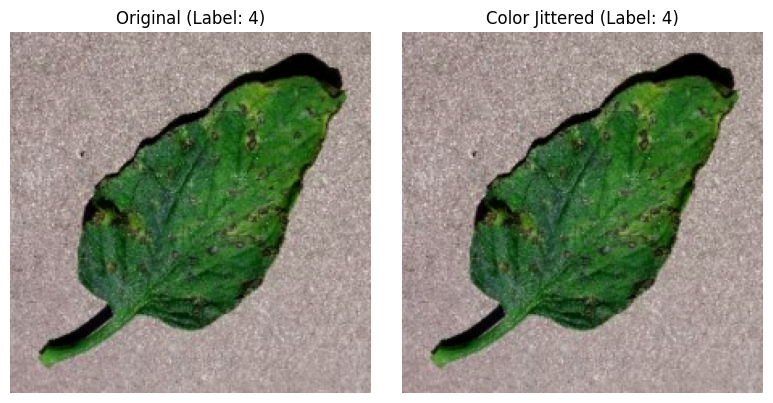

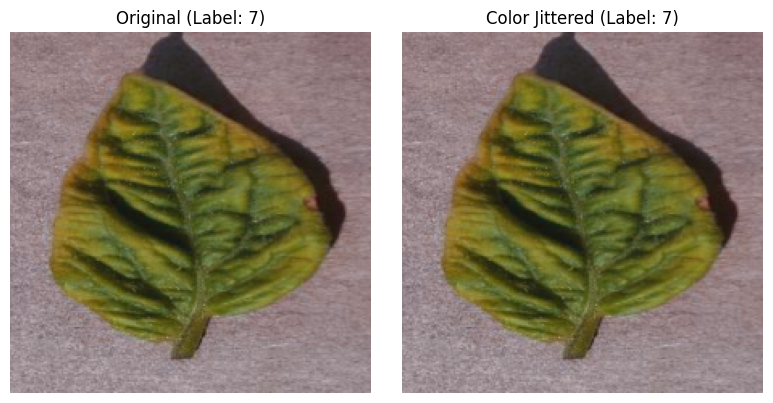

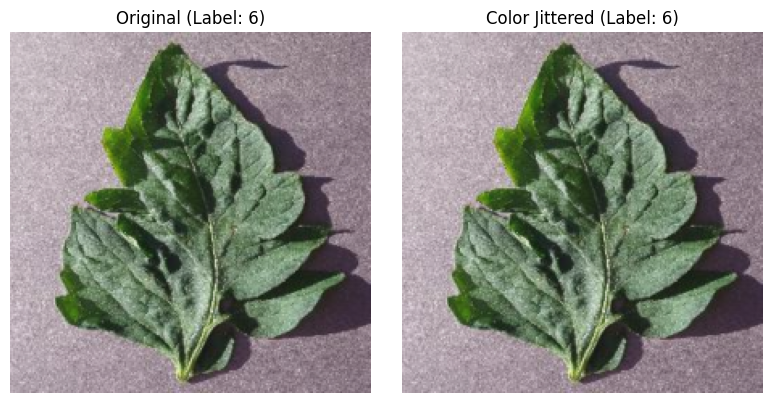

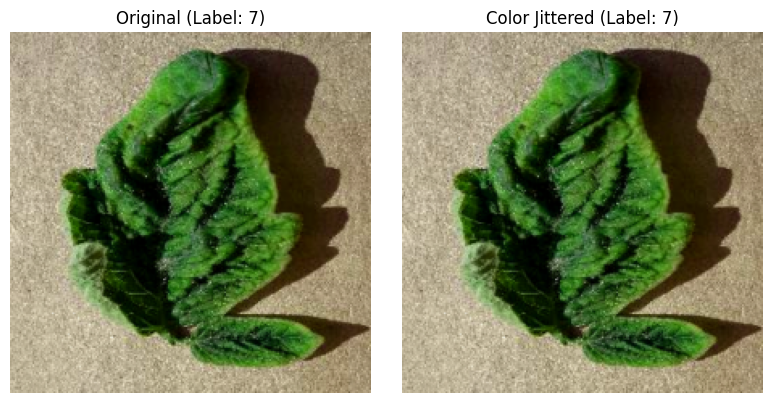

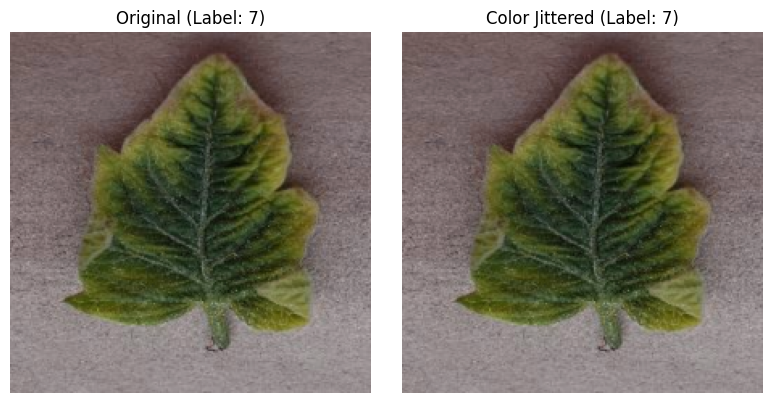

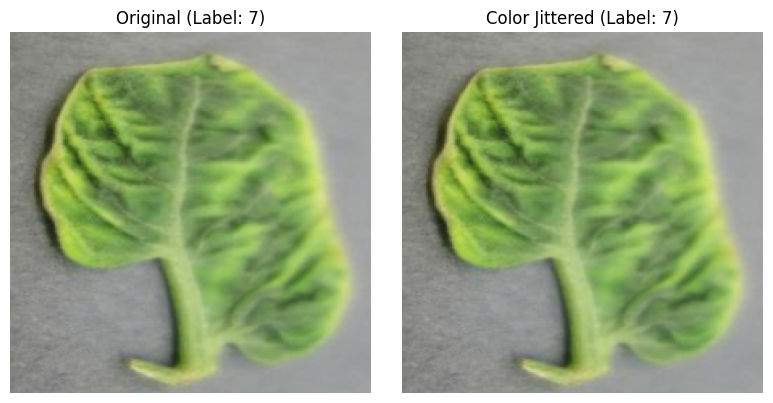

In [ ]:
# Assume the dataloader now returns: original image, color jittered image, and labels.
org_batch, color_jitter_batch, labels = next(data_iter)

num_to_show = min(10, org_batch.size(0))

for i in range(num_to_show):
    org_img = denormalize_and_convert(org_batch[i])
    jitter_img = denormalize_and_convert(org_batch[i])
    label_idx = labels[i].item()

    fig, axs = plt.subplots(1, 2, figsize=(8, 4))

    # Show original image (without color jitter)
    axs[0].imshow(org_img)
    axs[0].set_title(f"Original (Label: {label_idx})")
    axs[0].axis('off')

    # Show color jittered image
    axs[1].imshow(jitter_img)
    axs[1].set_title(f"Color Jittered (Label: {label_idx})")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()


# Ablation of DualStream structure(masking kMean stream and keep colorjittering stream)

In [ ]:
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader
from tqdm import tqdm  # for progress bars

# Define a single-stream LeViT model.
class SingleLeViT(nn.Module):
    def __init__(self, num_classes=10):
        super(SingleLeViT, self).__init__()
        # Create a LeViT model with pretrained weights.
        # Setting num_classes ensures the final classifier layer matches the dataset.
        # In this ablation experiment, we will use this model to process only the color-jittered (original) images.
        self.model = timm.create_model("levit_192", pretrained=True, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

# ---------------------------------------------
# Training script (settings are kept identical to the original LeViT training setup)
# ---------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create the single-stream model.
model = SingleLeViT(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 40

# Early stopping variables.
best_val_loss = float('inf')
best_val_acc = 0.0
patience = 10
trigger_times = 0
best_model_state = None  # Optional: save the best model state.

for epoch in range(num_epochs):
    # ---------------------------
    #  TRAINING
    # ---------------------------
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # Note: The data loader returns both original (color jittered) images and k-means segmented images.
    # In this experiment, we are masking (i.e., discarding) the k-means stream and using only
    # the original images (color jittered) for training.
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]", leave=False)
    for orig_images, kmeans_images, labels in train_bar:
        # We only use the original images for training.
        orig_images = orig_images.to(device)
        labels = labels.to(device)

        # Forward pass using only the color jitter (original) images.
        logits = model(orig_images)
        loss = criterion(logits, labels)

        # Backpropagation.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training statistics.
        running_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        train_bar.set_postfix(loss=loss.item())

    train_loss = running_loss / total_train
    train_acc = correct_train / total_train

    # ---------------------------
    #  VALIDATION
    # ---------------------------
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    # During validation, we again discard the k-means stream and use only the original images.
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [VAL]", leave=True)
    with torch.no_grad():
        for orig_images, kmeans_images, labels in val_bar:
            # Only use the original (color jittered) images.
            orig_images = orig_images.to(device)
            labels = labels.to(device)

            logits = model(orig_images)
            loss_val = criterion(logits, labels)

            running_val_loss += loss_val.item() * labels.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            val_bar.set_postfix(loss=loss_val.item())

    val_loss = running_val_loss / total_val
    val_acc = correct_val / total_val

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.3f}")

    # ---------------------------
    #  EARLY STOPPING CHECK
    # ---------------------------
    if val_loss < best_val_loss or val_acc > best_val_acc:
        best_val_loss = val_loss
        best_val_acc = val_acc
        trigger_times = 0
        best_model_state = model.state_dict()  # Optionally, save the best model state.
        print("Validation loss improved; saving model.")
    else:
        trigger_times += 1
        print(f"Early stopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered. Stopping training.")
            break

# Optionally, load the best model state after training.
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model state based on validation loss.")


In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm  # For progress bars

# Set the model to evaluation mode (disables dropout, batch norm updates, etc.).
model.eval()

# Define the loss function as used during training.
criterion = nn.CrossEntropyLoss()

# Initialize accumulators:
# running_test_loss will accumulate the total loss over all test samples.
# correct_test and total_test will be used to compute overall accuracy.
running_test_loss = 0.0
correct_test = 0
total_test = 0

# Create a progress bar for iterating over the test data.
# Note: Although test_loader returns both original and k-means images,
#       we use only the original images (color-jittered images) for evaluation.
test_bar = tqdm(test_loader, desc="Testing", leave=True)

with torch.no_grad():  # Disable gradient computation for faster inference.
    for orig_images, kmeans_images, labels in test_bar:
        # Move the original images and labels to the computation device (e.g., GPU).
        orig_images = orig_images.to(device)
        labels = labels.to(device)

        # Perform a forward pass using only the original images.
        logits = model(orig_images)

        # Compute the loss for the current batch.
        loss = criterion(logits, labels)

        # Accumulate the batch loss, weighted by the number of samples in the batch.
        running_test_loss += loss.item() * labels.size(0)

        # Determine predicted class indices from the logits.
        preds = torch.argmax(logits, dim=1)

        # Accumulate the count of correct predictions.
        correct_test += (preds == labels).sum().item()

        # Accumulate the total number of samples processed.
        total_test += labels.size(0)

        # Update the progress bar with the current batch loss.
        test_bar.set_postfix(loss=loss.item())

# Calculate average loss over the entire test set.
avg_test_loss = running_test_loss / total_test

# Calculate overall test accuracy.
test_accuracy = correct_test / total_test

# Print the final evaluation metrics.
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.3f}")
